In [1]:
import os, sys, json
import matplotlib.pyplot as plt
import numpy as np
sys.path.append("..")
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
# read from json
data = None
experiment_name = "fig9a"
with open("../../../output/oscar-nsdi26/experiments/" + experiment_name + ".json", "r") as f:
    data = json.load(f)

In [3]:
# Calculate the send rate from data{flowStatistics:[0:4]:sentPkt:[timeNs,sizeByte]}
# The send rate is calculated by the number Bytes sent in each time interval
send_rate_interval_ns = 1e4  # 10us
send_rate = []
flow_num = 2
for i in range(flow_num):
    send_rate.append([])
    wnd_start = data["flowStatistics"][i]["sentPkt"][0]["timeNs"]
    # the first point
    send_rate[i].append({"timeNs": wnd_start, "sendRateGbps": 0})
    wnd_data = 0
    for sentPkt in data["flowStatistics"][i]["sentPkt"]:
        if sentPkt["timeNs"] - wnd_start > 2*send_rate_interval_ns:
            # Gbps = bpns
            send_rate[i].append({"timeNs": wnd_start,
                                "sendRateGbps": wnd_data * 8 / (sentPkt["timeNs"] - wnd_start)})
            send_rate[i].append({"timeNs": sentPkt["timeNs"],
                                "sendRateGbps": wnd_data * 8 / (sentPkt["timeNs"] - wnd_start)})
            wnd_start = sentPkt["timeNs"]
            wnd_data = 0
        elif sentPkt["timeNs"] - wnd_start > send_rate_interval_ns:
            # Gbps = bpns
            send_rate[i].append({"timeNs": wnd_start + (sentPkt["timeNs"] - wnd_start)/2,
                                "sendRateGbps": wnd_data * 8 / (sentPkt["timeNs"] - wnd_start)})
            wnd_start = sentPkt["timeNs"]
            wnd_data = 0
        wnd_data += sentPkt["sizeByte"]
    # the last point
    send_rate[i].append({"timeNs": wnd_start + send_rate_interval_ns/2,
                         "sendRateGbps": 0})

switch_idx = 0
port_idx = 15
queue_idx = 0

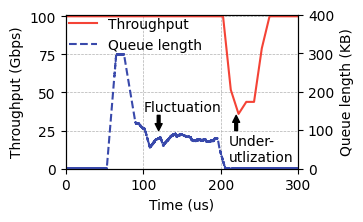

In [4]:
# draw the send rate in a new figure
fig = plt.figure(figsize=(3, 2))

ax1 = fig.add_subplot(111)
ax2 = ax1.twinx()
ax1.set_xlabel("Time (us)")
ax1.set_ylabel("Throughput (Gbps)")
ax2.set_ylabel("Queue length (KB)")

time_shift = 100e3
figure_shift = 50

color_rate = ["#F44336", "#1E88E5"]
color_queue = ["#3949AB", "#FB8C00"]
line = ["-", "--"]

l1 = ax1.plot([q["timeNs"] / 1e3 - time_shift - figure_shift for q in data["switchStatistics"][switch_idx]["portStats"][port_idx]["queueStats"][0]["deviceThroughput"]],
         [q["throughputBitps"] / 1e9 for q in data["switchStatistics"][switch_idx]["portStats"][port_idx]["queueStats"][0]["deviceThroughput"]],
         color = color_rate[0], linestyle = line[0], label="Throughput")
l2 = ax2.plot([q["timeNs"] / 1e3 - time_shift - figure_shift for q in data["switchStatistics"][switch_idx]["portStats"][port_idx]["queueStats"][0]["qLength"]],
         [q["lengthBytes"] / 1024 for q in data["switchStatistics"][switch_idx]["portStats"][port_idx]["queueStats"][0]["qLength"]],
         color = color_queue[0], linestyle = line[1], label="Queue length")


ax1.grid(True, linestyle='--', linewidth=0.5, which='both', axis='both')

ax1.set_xlim(0, 300)
ax1.set_ylim(0, 101)
ax2.set_ylim(0, 400)
plt.legend([l1[0],l2[0]], ["Throughput", 'Queue length'], loc='center', 
           ncol=1, frameon=False, bbox_to_anchor=(0.3, 0.87), prop={'size': 10})

ax1.annotate('Fluctuation', xy=(20, 30), xytext=(100, 38),
             xycoords='data',
             )
ax1.annotate('', xy=(120, 25), xytext=(120, 35),
             xycoords='data',
             arrowprops=dict(facecolor='black', shrink=0,
                             width=2, headlength=5, headwidth=5),
             )

ax1.annotate('Under-\nutlization', xy=(20, 30), xytext=(210, 5),
             xycoords='data',
             )
ax1.annotate('', xy=(220, 35), xytext=(220, 25),
             xycoords='data',
             arrowprops=dict(facecolor='black', shrink=0,
                             width=2, headlength=5, headwidth=5),
             )

plt.savefig("../figures/" + "fig9a" +
             ".pdf", bbox_inches='tight', dpi=600, format='pdf')